# Stock Market Case Study

In [69]:
##Going through the instructor's sample to put imports at the top, where they should be. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import glob

In [2]:
##I am using the Warnings package to get rid of any future warnings
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

# 1. Data Collection

In [8]:
##Glob lists the files in the directory. The *csv specified only to list csv files
glob.glob(r'C:\Users\impat\OneDrive\Desktop\GitHhub Repository\Stock Market Analytics\individual_stocks_5yr/*csv')

['C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\AAL_data.csv',
 'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\AAPL_data.csv',
 'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\AAP_data.csv',
 'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\ABBV_data.csv',
 'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\ABC_data.csv',
 'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\ABT_data.csv',
 'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\ACN_data.csv',
 'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\ADBE_data.csv',
 'C:\\Users\\impat\\OneDrive\

In [6]:
len(glob.glob(r'C:\Users\impat\OneDrive\Desktop\GitHhub Repository\Stock Market Analytics\individual_stocks_5yr/*csv')) ##total amount of files

505

In [ ]:
company_list = [
    'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\AAPL_data.csv',
    'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\AMZN_data.csv',
    'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\GOOG_data.csv',
    'C:\\Users\\impat\\OneDrive\\Desktop\\GitHhub Repository\\Stock Market Analytics\\individual_stocks_5yr\\MSFT_data.csv'  
]

In [10]:
##appends data to the dataframe through the listed files
all_data = pd.DataFrame()

for file in company_list:
    current_df = pd.read_csv(file)
    all_data = pd.concat([all_data, current_df], ignore_index=True)

In [11]:
all_data.shape ##all_data dimiensions

(4752, 7)

In [14]:
all_data.head(6) ##shows headers

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
5,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL


In [13]:
all_data['Name'].unique() ##Shows unique headers in an array

<StringArray>
['AAPL', 'AMZN', 'GOOG', 'MSFT']
Length: 4, dtype: str

# 2. Data Cleaning & Prep

In [19]:
all_data.columns ##showing column names

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='str')

In [20]:
all_data.dtypes ##showing data types of the data

date          str
open      float64
high      float64
low       float64
close     float64
volume      int64
Name          str
dtype: object

In [23]:
all_data['date'] =pd.to_datetime(all_data["date"]) ##converts date from str to date-time data

In [24]:
all_data.dtypes ##showing data types of the data to see the change. It should show datetime64[us] for date

date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name                 str
dtype: object

In [25]:
all_data.isnull().sum() ##Tells if missing value is data via a count

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [31]:
all_data.duplicated().sum() ## double checking null data

np.int64(0)

In [32]:
all_data[all_data["volume"]<=0] ## triple checking null data

,date,open,high,low,close,volume,Name


In [33]:
all_data['Name'].unique()

<StringArray>
['AAPL', 'AMZN', 'GOOG', 'MSFT']
Length: 4, dtype: str

In [34]:
all_data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [36]:
all_data = all_data.sort_values(["Name", "date"]) ##organized by name and date, looks like ascending order

# 3. Which is the Safest Stock to Invest?

In [37]:
## The least volitile stock options. Their std deviations fluctuate less. 

In [41]:
all_data["daily_return"] = all_data.groupby("Name")['close'].pct_change() ##calculate percent change per day and puts in daily_return column

In [44]:
risk = all_data.groupby('Name')['daily_return'].std() ## calculate standard deviations

In [45]:
safest_stock = risk.idxmin()

In [47]:
safest_stock ##it says google

'GOOG'

# 4. Which Stock made the Highest Money?

In [48]:
##Culmulitive reuturn

In [49]:
all_data["daily_return"]

0            NaN
1       0.010422
2      -0.025067
3      -0.001903
4      -0.000899
          ...   
4747   -0.007894
4748   -0.026310
4749   -0.041185
4750    0.037841
4751   -0.018833
Name: daily_return, Length: 4752, dtype: float64

In [52]:
(1 + all_data["daily_return"]).groupby(all_data["Name"]).cumprod() ##the one is for calc gorwth factors percents correctly

0            NaN
1       1.010422
2       0.985095
3       0.983220
4       0.982336
          ...   
4747    3.421416
4748    3.331397
4749    3.194192
4750    3.315064
4751    3.252632
Name: daily_return, Length: 4752, dtype: float64

In [53]:
all_data["cumulative_return"] = (1 + all_data["daily_return"]).groupby(all_data["Name"]).cumprod()

In [55]:
final_returns = all_data.groupby("Name")["cumulative_return"].last()
final_returns

Name
AAPL    2.351218
AMZN    5.408589
GOOG    1.877628
MSFT    3.252632
Name: cumulative_return, dtype: float64

In [56]:
best_stock = final_returns.idxmax()

<function matplotlib.pyplot.show(close=None, block=None)>

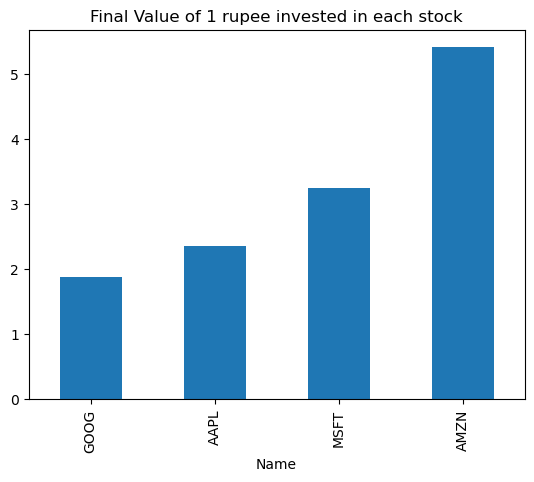

In [59]:
final_returns.sort_values().plot(kind= "bar")
plt.title("Final Value of 1 rupee invested in each stock")
plt.ylabel
plt.show

# 5. 1 Million Sage Investment Simulation at Amazon

In [60]:
investment = 1000000

In [62]:
df_best = all_data[all_data['Name'] == best_stock]

In [64]:
df_best["investment_value"] = df_best["cumulative_return"] * investment ##investment values over time

In [66]:
df_best["investment_value"].tail(1).values[0]

np.float64(5408589.425462884)

In [67]:
df_best.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cumulative_return', 'investment_value'],
      dtype='str')

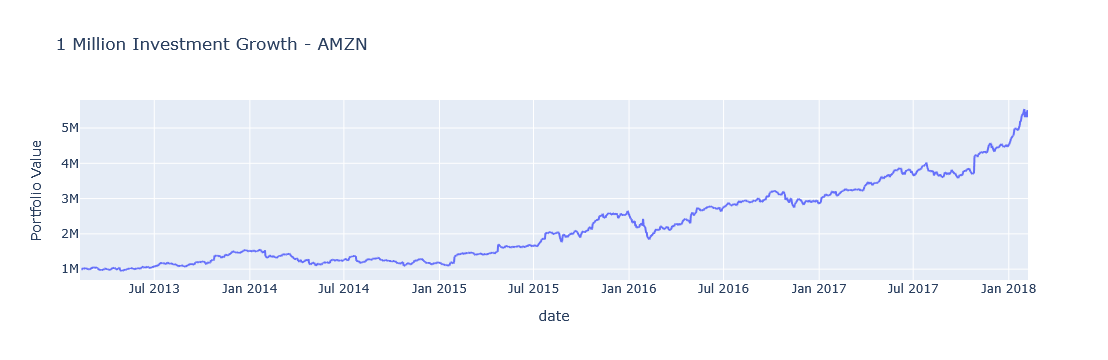

In [71]:
px.line(
    df_best,
    x = 'date',
    y = 'investment_value',
    title = f"1 Million Investment Growth - {best_stock}",
    labels = {
        'investment_value' : 'Portfolio Value'
    }
)

# 6. Market Crash Days: Worst Losses Analysis

In [77]:
all_data[all_data["Name"] == "AAPL"].nsmallest(5, 'daily_return')

,date,open,high,low,close,volume,Name,daily_return,cumulative_return
243,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,AAPL,-0.079927,1.066361
746,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,AAPL,-0.065707,1.376775
809,2016-04-27,96.0000,98.7100,95.6800,97.8200,114602142,AAPL,-0.062578,1.441620
638,2015-08-21,110.4300,111.9000,105.6450,105.7600,128275471,AAPL,-0.061163,1.558636
46,2013-04-17,60.0385,60.0857,56.8728,57.5428,236138966,AAPL,-0.054993,0.848036


In [100]:
worst_days = (
    all_data
    .sort_values("daily_return")
    .groupby("Name")
    .head(5)
    .reset_index(drop=True)
)

In [101]:
worst_days.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cumulative_return'],
      dtype='str')

In [102]:
worst_days = worst_days.reset_index(drop=True)

In [103]:
worst_days[["Name", "date" , "daily_return"]]

,Name,date,daily_return
0,MSFT,2013-07-19,-0.113995
1,AMZN,2014-01-31,-0.109972
2,AMZN,2014-04-25,-0.098828
3,AMZN,2014-07-25,-0.096484
4,MSFT,2015-01-27,-0.092534
5,AMZN,2014-10-24,-0.083403
6,AAPL,2014-01-28,-0.079927
7,AMZN,2016-01-29,-0.076100
8,MSFT,2016-04-22,-0.071710
9,AAPL,2016-01-27,-0.065707


In [104]:
worst_days.dtypes

date                 datetime64[us]
open                        float64
high                        float64
low                         float64
close                       float64
volume                        int64
Name                            str
daily_return                float64
cumulative_return           float64
dtype: object

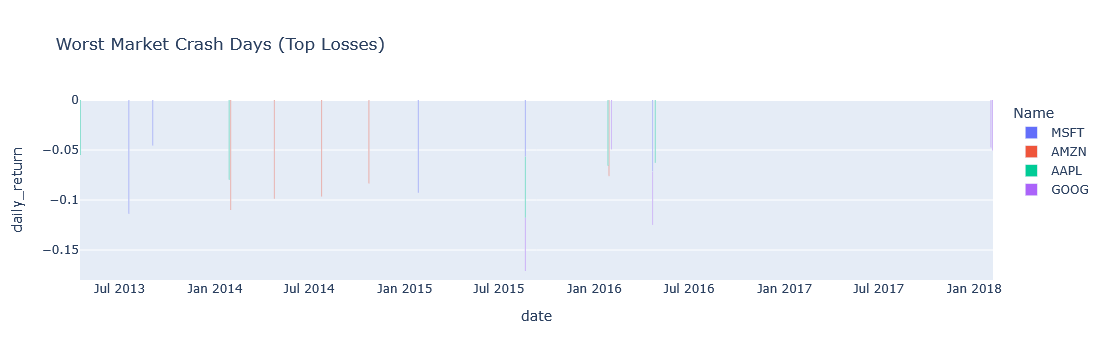

In [105]:
px.bar(
    worst_days,
    x = "date",
    y = "daily_return",
    color = "Name",
    title = "Worst Market Crash Days (Top Losses)"
)

In [108]:
worst_days["crash_label"] = worst_days["Name"] + "|" + worst_days["date"].dt.strftime("%y-%m-%d")
worst_days

,date,open,high,low,close,volume,Name,daily_return,cumulative_return,crash_label
0,2013-07-19,32.4000,32.6700,31.0200,31.4000,248354245,MSFT,-0.113995,1.139746,MSFT|13-07-19
1,2014-01-31,371.7600,375.4500,357.7600,358.6900,16181519,AMZN,-0.109972,1.369307,AMZN|14-01-31
2,2014-04-25,316.2500,316.4900,302.7100,303.8300,16186737,AMZN,-0.098828,1.159878,AMZN|14-04-25
3,2014-07-25,317.3000,324.8700,314.7600,324.0100,17855141,AMZN,-0.096484,1.236915,AMZN|14-07-25
4,2015-01-27,42.9500,43.2000,42.1050,42.6600,169163953,MSFT,-0.092534,1.548457,MSFT|15-01-27
5,2014-10-24,284.4000,293.8100,284.0000,287.0600,19805911,AMZN,-0.083403,1.095858,AMZN|14-10-24
6,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,AAPL,-0.079927,1.066361,AAPL|14-01-28
7,2016-01-29,571.9800,593.0000,570.0000,587.0000,14677550,AMZN,-0.076100,2.240886,AMZN|16-01-29
8,2016-04-22,51.9100,52.4297,50.7700,51.7800,126834091,MSFT,-0.071710,1.879492,MSFT|16-04-22
9,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,AAPL,-0.065707,1.376775,AAPL|16-01-27


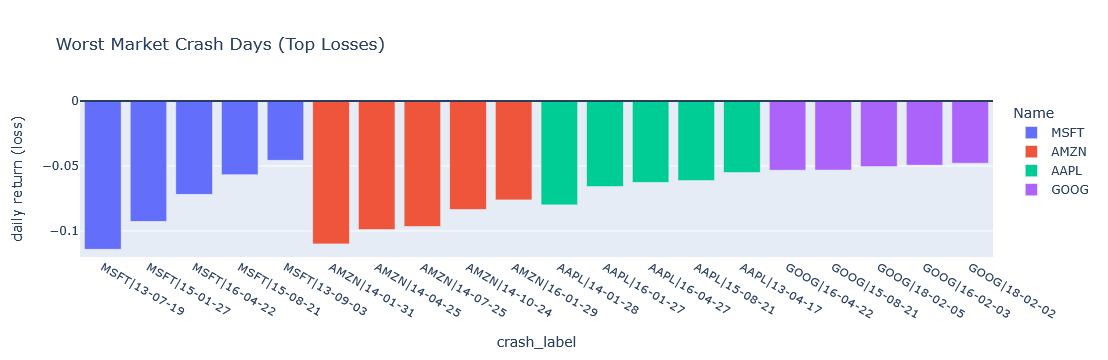

In [113]:
fig = px.bar(
    worst_days,
    x = "crash_label",
    y = "daily_return",
    color = "Name",
    title = "Worst Market Crash Days (Top Losses)",
    labels = {
        "daily_return" : "daily return (loss)"
    }
)
fig.add_hline(y = 0)
fig.show()

# 7. Moving Average (Trend Analysis)

In [114]:
all_data["close"]

0       67.8542
1       68.5614
2       66.8428
3       66.7156
4       66.6556
         ...   
4747    94.2600
4748    91.7800
4749    88.0000
4750    91.3300
4751    89.6100
Name: close, Length: 4752, dtype: float64

In [117]:
all_data["MA20"] = (
    all_data
    .groupby("Name")["close"]
    .rolling(20)
    .mean()
    .reset_index(level=0, drop=True)
)

In [118]:
all_data["MA50"] = (
    all_data
    .groupby("Name")["close"]
    .rolling(50)
    .mean()
    .reset_index(level=0, drop=True)
)

In [119]:
all_data.head(5)

,date,open,high,low,close,volume,Name,daily_return,cumulative_return,MA20,MA50
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN,NaN,NaN,NaN
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,0.010422,1.010422,NaN,NaN
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-0.025067,0.985095,NaN,NaN
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.001903,0.983220,NaN,NaN
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,-0.000899,0.982336,NaN,NaN


In [122]:
df_stock = all_data[all_data["Name"] =="AAPL"]

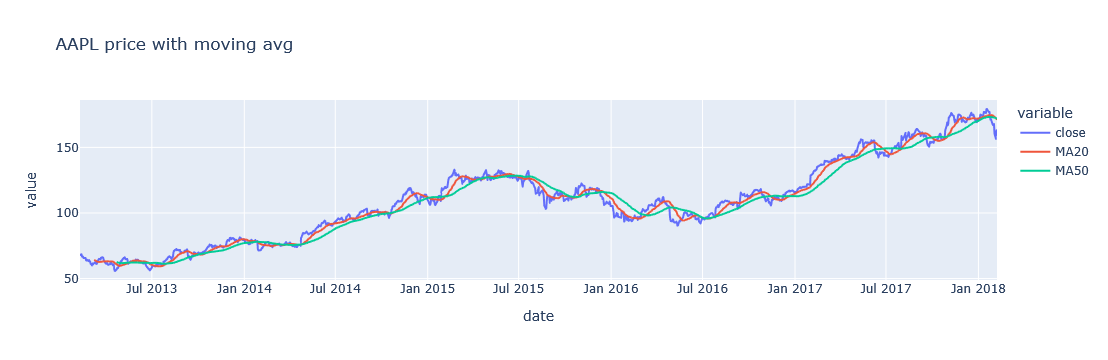

In [123]:
px.line(
    df_stock,
    x = "date",
    y = ['close', 'MA20', 'MA50'],
    title = "AAPL price with moving avg"
)

# 8. Best Month to invest in each stock

In [126]:
all_data["month_name"] = all_data["date"].dt.month_name()

In [129]:
monthly_returns = all_data.groupby(["Name", "month_name"]) ["daily_return"].mean().reset_index()

In [131]:
monthly_returns.columns

Index(['Name', 'month_name', 'daily_return'], dtype='str')

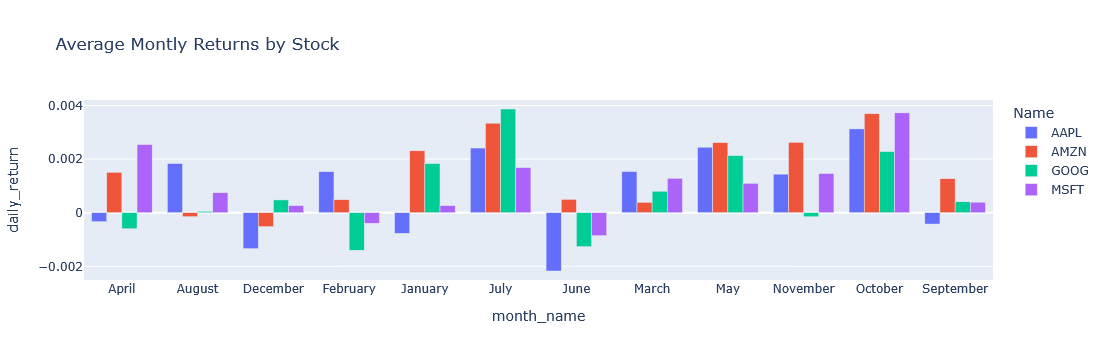

In [132]:
px.bar(monthly_returns,
       x = "month_name",
       y = "daily_return",
       color = "Name",
       barmode = "group",
       title = "Average Montly Returns by Stock"
      )